# Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')


# Load and Explore Datasets

In [4]:
# Load datasets
movies_df = pd.read_csv('../cleaned_archive/movies_metadata_box_office.csv')
keywords_df = pd.read_csv('../cleaned_archive/keywords_cleaned.csv')
credits_df = pd.read_csv('../cleaned_archive/credits_cleaned.csv')


# Explore datasets
print("Movies DataFrame shape:", movies_df.shape)
print("Movies columns:", movies_df.columns.tolist())
print("\nKeywords DataFrame shape:", keywords_df.shape)
print("Keywords columns:", keywords_df.columns.tolist())
print("\nCredits DataFrame shape:", credits_df.shape)
print("Credits columns:", credits_df.columns.tolist())

# Display first few rows
print("\nMovies DataFrame head:")
print(movies_df.head())
print("\nKeywords DataFrame head:")
print(keywords_df.head())

Movies DataFrame shape: (5356, 25)
Movies columns: ['id', 'title', 'original_title', 'budget', 'revenue', 'runtime', 'release_date', 'release_year', 'popularity', 'vote_average', 'vote_count', 'budget_outlier', 'revenue_outlier', 'runtime_outlier', 'adult', 'video', 'status', 'original_language', 'imdb_id', 'genres_list', 'production_companies_list', 'production_countries_list', 'spoken_languages_list', 'is_collection', 'overview']

Keywords DataFrame shape: (156602, 3)
Keywords columns: ['id', 'keyword_id', 'keyword_name']

Credits DataFrame shape: (45432, 5)
Credits columns: ['id', 'cast_list', 'cast_count', 'directors', 'writers']

Movies DataFrame head:
      id              title     original_title    budget    revenue  runtime  \
0    862          Toy Story          Toy Story  30000000  373554033     81.0   
1   8844            Jumanji            Jumanji  65000000  262797249    104.0   
2  31357  Waiting to Exhale  Waiting to Exhale  16000000   81452156    127.0   
3    949      

# Data Preprocessing for Analysis

In [5]:
# Merge movies with keywords
movies_keywords_df = pd.merge(movies_df, keywords_df, on='id', how='left')

# Handle missing values
movies_keywords_df['revenue'] = movies_keywords_df['revenue'].fillna(0)
movies_keywords_df['release_date'] = pd.to_datetime(movies_keywords_df['release_date'], errors='coerce')
movies_keywords_df['release_year'] = movies_keywords_df['release_date'].dt.year
movies_keywords_df['release_month'] = movies_keywords_df['release_date'].dt.month

# Filter out movies with zero revenue or invalid dates
movies_keywords_df = movies_keywords_df[(movies_keywords_df['revenue'] > 0) & (movies_keywords_df['release_date'].notna())]

# Create a movie-level dataset for regression modeling to avoid repeated keyword rows
movies_model_df = movies_keywords_df[['id', 'release_month', 'budget', 'revenue']].drop_duplicates(subset='id')

# Prepare keyword lists
keyword_revenue_df = movies_keywords_df.groupby('keyword_name')['revenue'].agg(['mean', 'count']).reset_index()
keyword_revenue_df = keyword_revenue_df.sort_values('mean', ascending=False)

print("Preprocessed DataFrame shape:", movies_keywords_df.shape)
print("Movie-level DataFrame shape:", movies_model_df.shape)
print("Keyword Revenue DataFrame head:")
print(keyword_revenue_df.head())

Preprocessed DataFrame shape: (43513, 28)
Movie-level DataFrame shape: (5356, 4)
Keyword Revenue DataFrame head:
               keyword_name          mean  count
347                anti war  2.787965e+09      1
9068               steerage  1.845034e+09      1
7952  rich woman - poor man  1.845034e+09      1
8173                salvage  1.845034e+09      1
6270             muscle car  1.506249e+09      1


# Analyze Release Date Impact on Revenue

In [6]:
# Group by release year
yearly_revenue = movies_keywords_df.groupby('release_year')['revenue'].mean().reset_index()

# Group by release month
monthly_revenue = movies_keywords_df.groupby('release_month')['revenue'].mean().reset_index()

print("Yearly Revenue Average:")
print(yearly_revenue)
print("\nMonthly Revenue Average:")
print(monthly_revenue)

Yearly Revenue Average:
    release_year       revenue
0           1915  9.189561e+06
1           1916  8.000000e+06
2           1918  8.000000e+06
3           1921  2.500000e+06
4           1922  4.002000e+05
..           ...           ...
94          2013  1.505307e+08
95          2014  1.683345e+08
96          2015  1.666305e+08
97          2016  1.582423e+08
98          2017  2.424742e+08

[99 rows x 2 columns]

Monthly Revenue Average:
    release_month       revenue
0               1  4.815625e+07
1               2  8.364660e+07
2               3  1.013270e+08
3               4  1.081297e+08
4               5  1.781694e+08
5               6  1.789713e+08
6               7  1.469844e+08
7               8  7.493033e+07
8               9  5.614735e+07
9              10  7.977077e+07
10             11  1.682479e+08
11             12  1.439564e+08


# Analyze Keywords Impact on Revenue

In [7]:
# Top keywords by average revenue
top_keywords = keyword_revenue_df.head(10)
print("Top 10 Keywords by Average Revenue:")
print(top_keywords)

# Keywords with high frequency
frequent_keywords = keyword_revenue_df[keyword_revenue_df['count'] > 5].head(10)
print("\nFrequent Keywords (count > 5) by Average Revenue:")
print(frequent_keywords)

Top 10 Keywords by Average Revenue:
               keyword_name          mean  count
347                anti war  2.787965e+09      1
9068               steerage  1.845034e+09      1
7952  rich woman - poor man  1.845034e+09      1
8173                salvage  1.845034e+09      1
6270             muscle car  1.506249e+09      1
7337        power relations  1.413503e+09      2
8887              space war  1.394790e+09      2
8768                snowman  1.274219e+09      1
6207       mountain climber  1.274219e+09      1
6319       mysterious woman  1.238765e+09      1

Frequent Keywords (count > 5) by Average Revenue:
                    keyword_name          mean  count
6739                        orcs  8.979636e+08      7
4997                        jedi  8.183514e+08      7
4448                      hobbit  7.939418e+08      6
5782   marvel cinematic universe  7.725799e+08     14
6026                     minions  7.418768e+08      6
9800                transformers  7.286585e+08    

# Visualize Release Date vs. Revenue

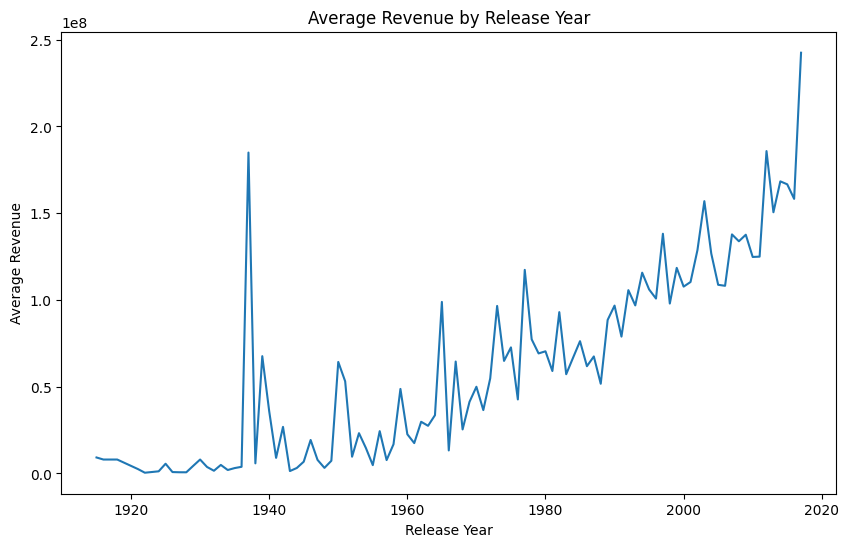

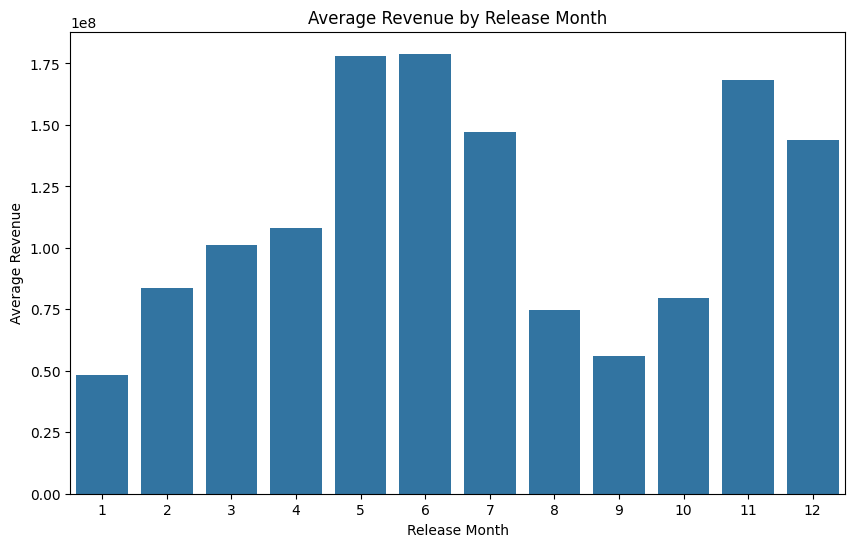

In [8]:
# Line chart for yearly revenue
plt.figure(figsize=(10, 6))
sns.lineplot(data=yearly_revenue, x='release_year', y='revenue')
plt.title('Average Revenue by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Average Revenue')
plt.show()

# Bar chart for monthly revenue
plt.figure(figsize=(10, 6))
sns.barplot(data=monthly_revenue, x='release_month', y='revenue')
plt.title('Average Revenue by Release Month')
plt.xlabel('Release Month')
plt.ylabel('Average Revenue')
plt.show()

# Visualize Keywords vs. Revenue

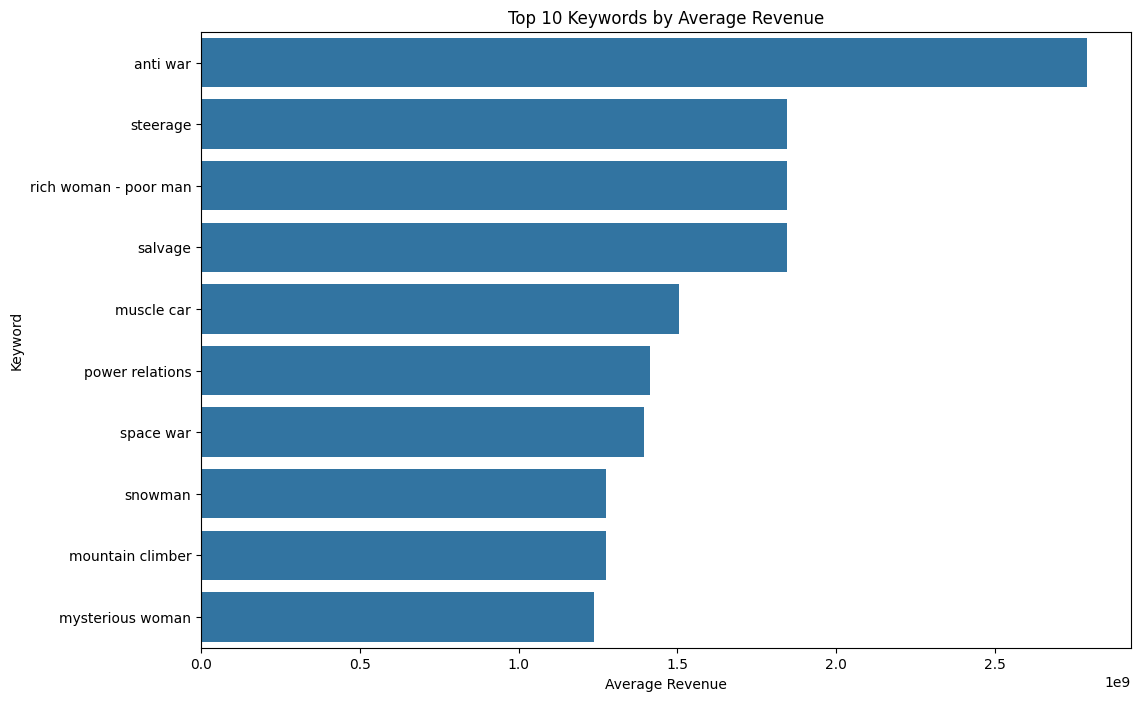

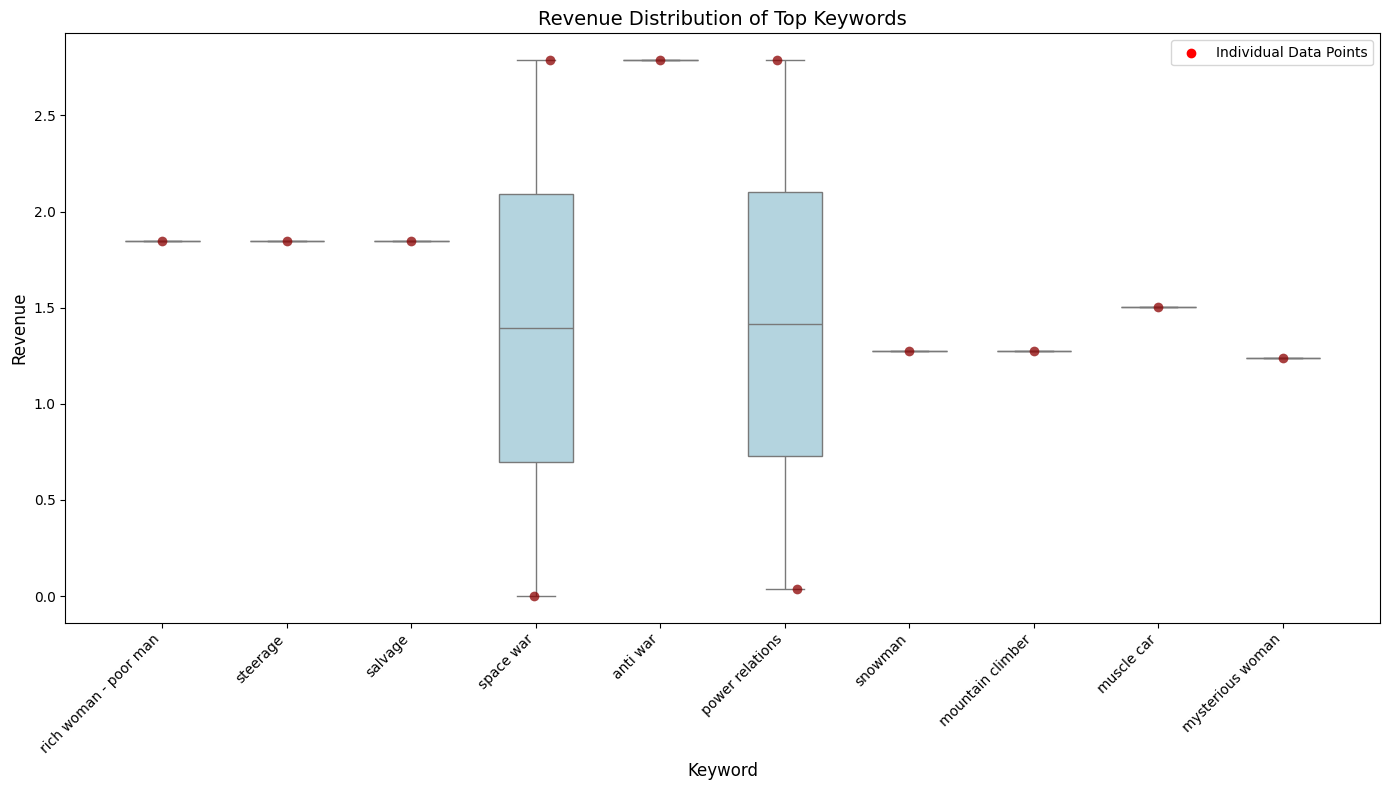

In [9]:
# Bar chart for top keywords by average revenue
plt.figure(figsize=(12, 8))
sns.barplot(data=top_keywords, x='mean', y='keyword_name')
plt.title('Top 10 Keywords by Average Revenue')
plt.xlabel('Average Revenue')
plt.ylabel('Keyword')
plt.show()

# Box plot for revenue distribution by keyword (for top keywords)
top_keyword_names = top_keywords['keyword_name'].tolist()
filtered_df = movies_keywords_df[movies_keywords_df['keyword_name'].isin(top_keyword_names)]

plt.figure(figsize=(14, 8))

sns.boxplot(
    data=filtered_df,
    x="keyword_name",
    y="revenue",
    showfliers=False,
    width=0.6,
    color="lightblue"
)

sns.stripplot(
    data=filtered_df,
    x="keyword_name",
    y="revenue",
    color="darkred",
    size=7,
    jitter=0.25,
    alpha=0.75
)
plt.ylabel("Revenue (Billion USD)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x/1e9:.1f}"))
plt.scatter([], [], color='red', label='Individual Data Points')
plt.legend(loc='upper right')
plt.title("Revenue Distribution of Top Keywords", fontsize=14)
plt.xlabel("Keyword", fontsize=12)
plt.ylabel("Revenue", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Statistical Modeling for Revenue Prediction

This section uses movie-level data for regression to avoid each movie being counted repeatedly in the sample due to keywords.

Regression dataset shape: (5356, 3)
Mean Squared Error: 1.4037855791904724e+16


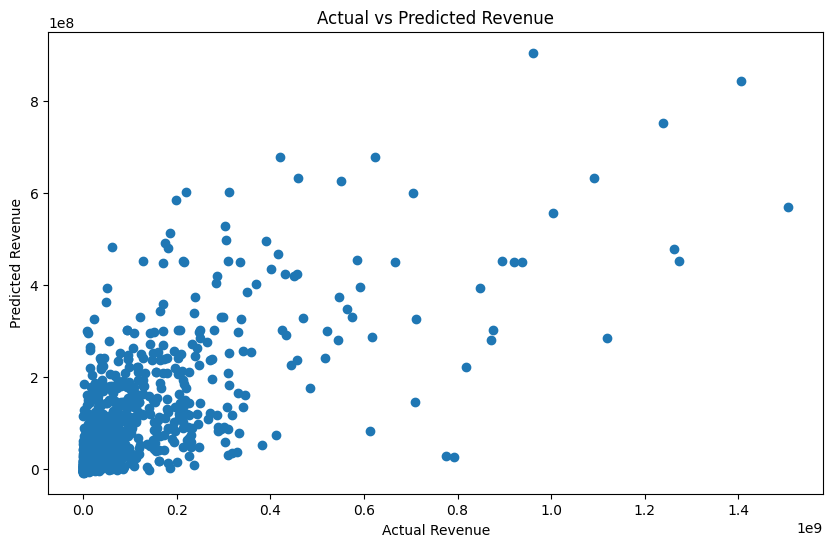

In [10]:
# Simple linear regression using release month and budget
features = ['release_month', 'budget']
target = 'revenue'

# Prepare data using movie-level records only
model_df = movies_model_df[features + [target]].dropna()
X = model_df[features]
y = model_df[target]
print(f"Regression dataset shape: {model_df.shape}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

# Plot predictions vs actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue')
plt.title('Actual vs Predicted Revenue')
plt.show()